**RoBERTa vs TF-IDF: The Real Cost of Better Twitter Sentiment**

> End-to-end NLP workflow comparing a strong classical baseline against a fine-tuned Transformer for `negative`, `neutral`, and `positive` sentiment classification.

---

**1) Project Objective**

- Build a robust sentiment classifier for Twitter text.
- Compare two modeling families under the same data split:
  1. Classical NLP (`TF-IDF + linear models`)
  2. Transformer fine-tuning (`cardiffnlp/twitter-roberta-base-sentiment-latest`)
- Optimize for **macro F1** (not only accuracy), since classes are not perfectly balanced.

---

**2) Dataset**

- Source file: `Tweets.csv`
- Original shape: **(27,481, 4)**
- Columns used: `text`, `sentiment`
- After cleaning nulls and filtering valid labels: **(27,480, 2)**

Class distribution after cleaning:
- `neutral`: 11,117 (40.45%)
- `positive`: 8,582 (31.23%)
- `negative`: 7,781 (28.32%)

---

**3) EDA Highlights**

- Basic quality checks:
  - Empty texts: 0
  - Duplicates (`text + sentiment`): 0
  - Duplicates (`text` only): 0
- Structural text features analyzed:
  - character length, word count
  - uppercase ratio
  - exclamation/question marks
  - URL, mention, hashtag counts
- Token and bigram frequency analysis by class.
- Negation-focused analysis (`not`, `never`, `don't`, etc.) to validate sentiment signal.

---

**4) Preprocessing Strategy**

**Classical pipeline**
- Lowercasing
- URL removal
- Mention normalization (`@user`)
- Hashtag normalization (`#happy` -> `happy`)
- Whitespace normalization

**Transformer pipeline**
- Minimal preprocessing (mainly whitespace normalization) to preserve punctuation, case, and social-media cues.
- Rationale: Twitter Transformers are pre-trained on noisy real-world text; over-cleaning can remove useful semantic/emotional signals.

---

**5) Data Split and Leakage Check**

- Stratified split: **80% train / 20% test**
- Final sizes:
  - Train: 21,984
  - Test: 5,496
- Empty strings after classical preprocessing handled safely with placeholder (`__empty__`).
- Overlap check on preprocessed unique texts:
  - Overlap train-test: **21**
  - Overlap ratio over unique test texts: **0.0038**

---

**6) Classical Modeling**

**Feature engineering**
- `TF-IDF word` (`ngram_range=(1,2)`)
- `TF-IDF char_wb` (`ngram_range=(3,5)`)
- Combined feature space (`word + char`) via `FeatureUnion`

**Algorithms tested**
- Logistic Regression (`class_weight` variants)
- Linear SVC (`class_weight` variants)

**Benchmark summary (before fine grid)**

| Model | CV F1 Macro (mean) | Test F1 Macro |
|---|---:|---:|
| wordchar_lr_balanced | 0.7079 | 0.7143 |
| char_lr_balanced | 0.7043 | 0.7100 |
| word_lr_balanced | 0.6872 | 0.6903 |
| wordchar_svc_balanced | 0.6843 | 0.6834 |
| word_lr_unbalanced | 0.6809 | 0.6797 |

**Mini-grid best config**
- **Best classical model**: `LogisticRegression`, `C=0.5`, `class_weight='balanced'`
- **Test F1 Macro**: **0.7145**
- This became the final classical reference.

---

**7) Transformer Fine-Tuning**

**Model**
- `cardiffnlp/twitter-roberta-base-sentiment-latest`

**Training setup**
- Train/Val split from train set (stratified)
- 3 epochs
- Batch sizes:
  - train: 16
  - eval: 32
- Learning rate: `2e-5`
- Weight decay: `0.01`
- Early stopping (`patience=2`)
- Metric for model selection: **macro F1**
- Hardware: CUDA-enabled GPU (RTX 5070 Ti)

**Validation trend (example run)**
- Epoch 1: F1 macro ~ 0.811
- Epoch 2: F1 macro ~ 0.805
- Epoch 3: F1 macro ~ 0.815

**Test performance**
- **Transformer F1 Macro (test): 0.8050**
- Fit time: ~126.77 s
- Inference time on full test set: ~2.87 s

Class-level metrics (Transformer, test):
- `negative`: precision 0.7955 / recall 0.8123 / f1 0.8038
- `neutral`: precision 0.7755 / recall 0.7566 / f1 0.7659
- `positive`: precision 0.8400 / recall 0.8503 / f1 0.8452

---

**8) Final Comparison**

| Model | Test F1 Macro | Fit Time (s) | Inference Time (s, full test) |
|---|---:|---:|---:|
| Classical (best grid LR) | **0.7145** | ~3.86 | ~0.29 |
| Transformer fine-tuned | **0.8050** | ~126.77 | ~2.87 |

- Transformer improves macro F1 by about **+0.09** absolute.
- The gain is substantial and consistent across classes, especially for `positive` and `negative`.
- `neutral` remains the hardest class, as expected in Twitter sentiment tasks.

---

**9) Why Loss and F1 Can Move Differently**

- Validation loss can increase while F1 stays stable/improves because:
  - Cross-entropy penalizes confidence calibration.
  - F1 only cares about final class decisions.
- Model selection by macro F1 is appropriate for this task.

---

**10) Saved Artifacts**

Generated artifacts:
- `artifacts/reports/final_comparison.csv`
- `artifacts/predictions/error_comparison.csv`
- `artifacts/models/classic/best_classic_pipeline.pkl`
- `artifacts/models/classic/metadata.json`
- `artifacts/models/transformer/twitter_roberta_finetuned/`
- `artifacts/models/transformer/metadata.json`

---

**11) Reproducibility**

- Fixed random seed (`SEED=42`) across split and training workflows.
- Same test split used for both model families to ensure fair comparison.

---

**12) Next Steps**

1. Add confidence calibration (temperature scaling).
2. Analyze confusion concentrated in `neutral` class.
3. Perform multi-seed runs for confidence intervals.
4. Deploy best model with latency-aware optimizations (batching, quantization if needed).

---

**Author Note**

This notebook intentionally includes both a strong classical baseline and a modern Transformer approach to provide a realistic quality-vs-cost comparison for production decisions.

## 1) Setup

In [1]:
import os
import re
import random
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, ParameterGrid
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

## 2) Carga y chequeos iniciales

In [2]:
DATA_PATH = 'Tweets.csv'

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'No se encontro {DATA_PATH} en el directorio actual')

df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head(3))
display(df.info())

Shape: (27481, 4)


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative


<class 'pandas.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   textID         27481 non-null  str  
 1   text           27480 non-null  str  
 2   selected_text  27480 non-null  str  
 3   sentiment      27481 non-null  str  
dtypes: str(4)
memory usage: 4.1 MB


None

In [3]:
required_cols = ['text', 'sentiment']
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f'Faltan columnas requeridas: {missing_cols}')

df = df[required_cols].copy()
df = df.dropna(subset=['text', 'sentiment']).reset_index(drop=True)
df['text'] = df['text'].astype(str)

valid_labels = {'negative', 'neutral', 'positive'}
df = df[df['sentiment'].isin(valid_labels)].reset_index(drop=True)

print('Shape despues de limpieza basica:', df.shape)
print(df['sentiment'].value_counts())

Shape despues de limpieza basica: (27480, 2)
sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


## 3) EDA profundo

,count,pct
sentiment,,
neutral,11117,40.45
positive,8582,31.23
negative,7781,28.32


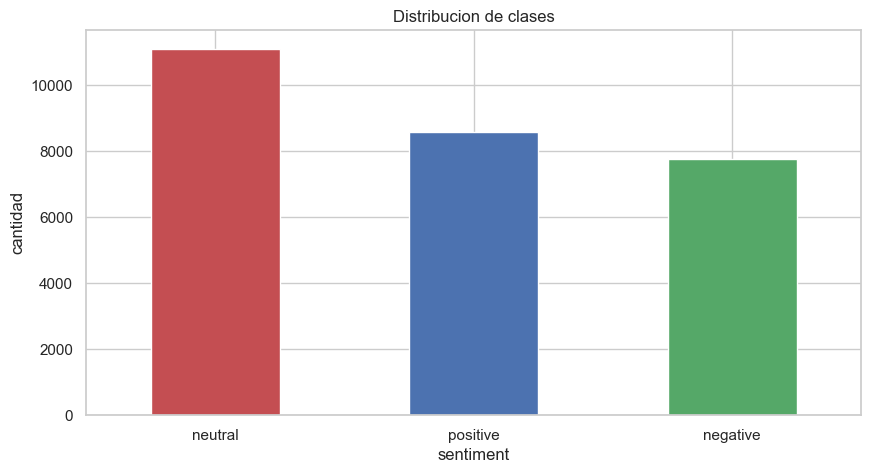

In [4]:
# 3.1 Distribucion de clases
class_counts = df['sentiment'].value_counts()
class_props = df['sentiment'].value_counts(normalize=True).mul(100).round(2)

display(pd.DataFrame({'count': class_counts, 'pct': class_props}))

ax = class_counts.plot(kind='bar', color=['#c44e52', '#4c72b0', '#55a868'])
ax.set_title('Distribucion de clases')
ax.set_xlabel('sentiment')
ax.set_ylabel('cantidad')
plt.xticks(rotation=0)
plt.show()

In [5]:
# 3.2 Duplicados y textos vacios
n_empty = (df['text'].str.strip() == '').sum()
n_dups = df.duplicated(subset=['text', 'sentiment']).sum()
n_dups_text_only = df.duplicated(subset=['text']).sum()

print('Textos vacios:', n_empty)
print('Duplicados (text + sentiment):', n_dups)
print('Duplicados (solo text):', n_dups_text_only)

Textos vacios: 0
Duplicados (text + sentiment): 0
Duplicados (solo text): 0


In [6]:
# 3.3 Features de longitud y estructura
df['char_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()
df['is_upper_ratio'] = df['text'].apply(lambda t: sum(ch.isupper() for ch in t) / max(len(t), 1))
df['excl_count'] = df['text'].str.count('!')
df['quest_count'] = df['text'].str.count('\?')
df['url_count'] = df['text'].str.count(r'http\S+|www\.\S+')
df['mention_count'] = df['text'].str.count(r'@\w+')
df['hashtag_count'] = df['text'].str.count(r'#\w+')

display(df[['char_len', 'word_len', 'is_upper_ratio', 'excl_count', 'quest_count', 'url_count', 'mention_count', 'hashtag_count']].describe().T)

,count,mean,std,min,25%,50%,75%,max
char_len,27480.0,68.330022,35.603870,3.0,39.0,64.000000,97.000000,141.0
word_len,27480.0,12.902875,6.925938,1.0,7.0,12.000000,18.000000,33.0
is_upper_ratio,27480.0,0.044576,0.077850,0.0,0.0,0.028571,0.054054,1.0
excl_count,27480.0,0.556623,1.316141,0.0,0.0,0.000000,1.000000,59.0
quest_count,27480.0,0.155240,0.922598,0.0,0.0,0.000000,0.000000,98.0
url_count,27480.0,0.047744,0.219120,0.0,0.0,0.000000,0.000000,4.0
mention_count,27480.0,0.002693,0.051824,0.0,0.0,0.000000,0.000000,1.0
hashtag_count,27480.0,0.021798,0.168257,0.0,0.0,0.000000,0.000000,5.0


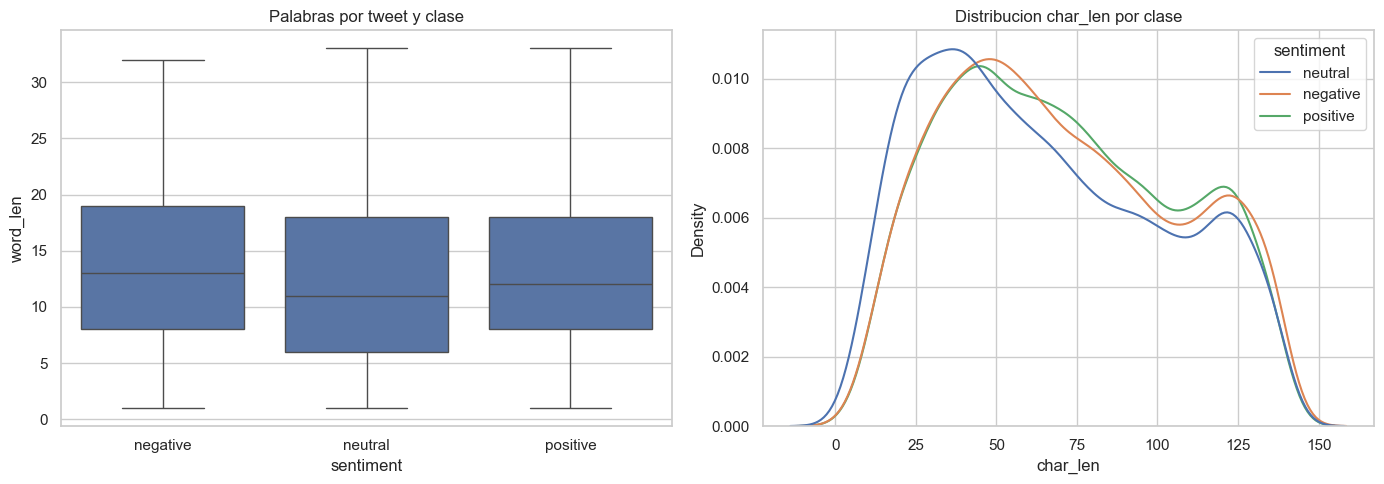

In [7]:
# 3.4 Longitud por clase
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='sentiment', y='word_len', ax=axes[0], order=['negative', 'neutral', 'positive'])
axes[0].set_title('Palabras por tweet y clase')

sns.kdeplot(data=df, x='char_len', hue='sentiment', common_norm=False, ax=axes[1])
axes[1].set_title('Distribucion char_len por clase')

plt.tight_layout()
plt.show()

In [8]:
# 3.5 Analisis de tokens frecuentes por clase (sin stopwords basico)
stop_basic = {
    'the', 'a', 'an', 'and', 'or', 'to', 'of', 'in', 'on', 'for', 'is', 'are', 'it', 'this', 'that',
    'i', 'you', 'he', 'she', 'we', 'they', 'me', 'my', 'your', 'our', 'their', 'im', 'ive', 'rt'
}

def simple_tokens(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' @user ', text)
    text = re.sub(r'#(\w+)', r' \1 ', text)
    text = re.sub(r'[^a-z0-9_\s\']', ' ', text)
    toks = [t for t in text.split() if len(t) > 2 and t not in stop_basic]
    return toks

for label in ['negative', 'neutral', 'positive']:
    pool = []
    for t in df.loc[df['sentiment'] == label, 'text'].values:
        pool.extend(simple_tokens(t))
    top = Counter(pool).most_common(15)
    top_df = pd.DataFrame(top, columns=['token', 'count'])
    print(f'\nTop tokens - {label}')
    display(top_df)


Top tokens - negative


,token,count
0,not,819
1,have,757
2,but,725
3,just,691
4,can,526
5,now,523
6,with,513
7,was,511
8,like,478
9,out,447



Top tokens - neutral


,token,count
0,but,1145
1,have,1012
2,just,921
3,with,834
4,not,756
5,was,672
6,can,651
7,now,643
8,out,634
9,get,626



Top tokens - positive


,token,count
0,day,1258
1,good,1062
2,love,886
3,happy,856
4,have,831
5,with,751
6,all,675
7,just,660
8,was,652
9,thanks,567


In [9]:
# 3.6 Top bigramas por clase
def top_ngrams(texts, ngram_range=(2, 2), top_k=15):
    vec = CountVectorizer(ngram_range=ngram_range, min_df=2, token_pattern=r'(?u)\b\w+\b')
    X = vec.fit_transform(texts)
    sums = np.asarray(X.sum(axis=0)).ravel()
    idx = np.argsort(sums)[::-1][:top_k]
    terms = vec.get_feature_names_out()
    return pd.DataFrame({'ngram': terms[idx], 'count': sums[idx]})

for label in ['negative', 'neutral', 'positive']:
    texts = df.loc[df['sentiment'] == label, 'text'].astype(str).tolist()
    print(f'\nTop bigramas - {label}')
    display(top_ngrams(texts, ngram_range=(2, 2), top_k=12))


Top bigramas - negative


,ngram,count
0,i m,908
1,it s,382
2,can t,343
3,don t,343
4,i have,299
5,i can,249
6,in the,244
7,and i,240
8,going to,235
9,i miss,235



Top bigramas - neutral


,ngram,count
0,i m,776
1,it s,475
2,don t,353
3,in the,336
4,going to,312
5,i have,299
6,but i,292
7,i can,275
8,can t,271
9,to go,238



Top bigramas - positive


,ngram,count
0,i m,577
1,i love,416
2,it s,365
3,s day,343
4,mother s,329
5,happy mother,263
6,have a,262
7,in the,242
8,mothers day,230
9,for the,230


,mean,median,max
sentiment,,,
negative,0.191364,0.0,9
neutral,0.133219,0.0,5
positive,0.068632,0.0,4


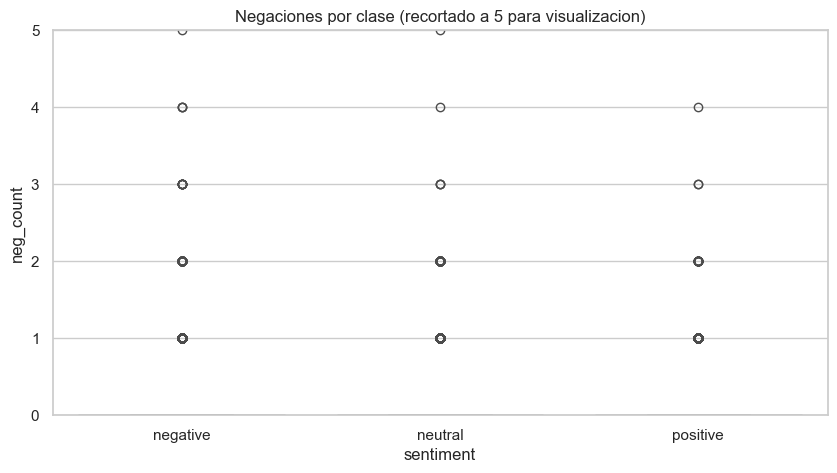

In [10]:
# 3.7 Negaciones por clase (senal clave para sentimiento)
neg_tokens = ['not', 'no', 'never', "don't", "can't", "won't", "isn't", "didn't", "wasn't"]
pattern_neg = r'\b(?:' + '|'.join([re.escape(t) for t in neg_tokens]) + r')\b'

tmp = df.copy()
tmp['neg_count'] = tmp['text'].str.lower().str.count(pattern_neg)

neg_summary = tmp.groupby('sentiment')['neg_count'].agg(['mean', 'median', 'max'])
display(neg_summary)

sns.boxplot(data=tmp, x='sentiment', y='neg_count', order=['negative', 'neutral', 'positive'])
plt.ylim(0, 5)
plt.title('Negaciones por clase (recortado a 5 para visualizacion)')
plt.show()

## 4) Diseno de procesamiento

Separamos procesamiento segun ruta:
- **Ruta clasica (TF-IDF):** limpieza ligera y normalizacion de patrones Twitter.
- **Ruta transformer:** limpieza minima para no perder senales semanticas.

In [11]:
def preprocess_classic(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'@\w+', ' @user ', text)
    text = re.sub(r'#(\w+)', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_transformer(text: str) -> str:
    # limpieza minima: solo remover espacios repetidos
    return re.sub(r'\s+', ' ', str(text)).strip()

sample = df.sample(8, random_state=SEED).copy()
sample['classic'] = sample['text'].apply(preprocess_classic)
sample['transformer'] = sample['text'].apply(preprocess_transformer)
display(sample[['sentiment', 'text', 'classic', 'transformer']])

,sentiment,text,classic,transformer
1588,positive,Enjoy! Family trumps everything,enjoy! family trumps everything,Enjoy! Family trumps everything
10413,negative,--of them kinda turns me off of it all. And ...,--of them kinda turns me off of it all. and th...,--of them kinda turns me off of it all. And th...
6561,neutral,Clive it`s my birthday pat me http://apps.fac...,clive it`s my birthday pat me,Clive it`s my birthday pat me http://apps.face...
2602,positive,congrats hey,congrats hey,congrats hey
4003,neutral,is texting,is texting,is texting
1569,neutral,Do you have any idea when the (not so) patien...,do you have any idea when the (not so) patient...,Do you have any idea when the (not so) patient...
27231,neutral,Tell him where...,tell him where...,Tell him where...
8285,negative,"Ooooh, I`m jealous I might try and get some ...","ooooh, i`m jealous i might try and get some fo...","Ooooh, I`m jealous I might try and get some fo..."


In [12]:
# chequeo: vacios post-procesamiento
tmp_classic = df['text'].apply(preprocess_classic)
tmp_tf = df['text'].apply(preprocess_transformer)

print('Vacios classic:', (tmp_classic.str.strip() == '').sum())
print('Vacios transformer:', (tmp_tf.str.strip() == '').sum())

Vacios classic: 1
Vacios transformer: 0


## 5) Split robusto + control de leakage

In [13]:
X = df['text']
y = df['sentiment']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

X_train_c = X_train_raw.apply(preprocess_classic).replace('', '__empty__')
X_test_c = X_test_raw.apply(preprocess_classic).replace('', '__empty__')

print('Train size:', len(X_train_c), ' | Test size:', len(X_test_c))
print('Vacios en train (despues de replace):', (X_train_c.str.strip() == '').sum())
print('Vacios en test  (despues de replace):', (X_test_c.str.strip() == '').sum())

Train size: 21984  | Test size: 5496
Vacios en train (despues de replace): 0
Vacios en test  (despues de replace): 0


In [14]:
# Leakage check: textos identicos en train/test tras preprocess
train_set = set(X_train_c.values)
test_set = set(X_test_c.values)
overlap = train_set.intersection(test_set)

overlap_ratio = len(overlap) / max(len(test_set), 1)
print(f'Overlap train-test (textos unicos): {len(overlap)} | ratio sobre test_unico: {overlap_ratio:.4f}')

if len(overlap) > 0:
    overlap_samples = pd.Series(list(overlap)).sample(min(5, len(overlap)), random_state=SEED)
    display(overlap_samples.to_frame('text_overlap_ejemplo'))

Overlap train-test (textos unicos): 21 | ratio sobre test_unico: 0.0038


,text_overlap_ejemplo
0,iphone is doing that 'not opening downloaded a...
17,made a little cover for my iphone. the birds a...
15,tummy hurts
1,i cant afford it go to school here ? !!
8,- square b - she is sad because she wasn`t the...


## 6) Benchmark de variantes TF-IDF (word vs char vs combinado)

In [15]:
def make_word_tfidf():
    return TfidfVectorizer(
        analyzer='word',
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        max_features=60000,
    )

def make_char_tfidf():
    return TfidfVectorizer(
        analyzer='char_wb',
        ngram_range=(3, 5),
        min_df=2,
        sublinear_tf=True,
        max_features=90000,
    )

def make_union_tfidf():
    # IMPORTANTE:
    # Sin FunctionTransformer(lambda x: x) para que el pipeline sea serializable con joblib.
    return FeatureUnion([
        ('word_tfidf', make_word_tfidf()),
        ('char_tfidf', make_char_tfidf()),
    ])

def evaluate_pipeline(name, pipeline, X_train, y_train, X_test, y_test):
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    cv_out = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        return_train_score=False,
    )

    t0 = time.perf_counter()
    pipeline.fit(X_train, y_train)
    fit_time = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred = pipeline.predict(X_test)
    infer_time = time.perf_counter() - t1

    return {
        'name': name,
        'cv_f1_macro_mean': float(np.mean(cv_out['test_score'])),
        'cv_f1_macro_std': float(np.std(cv_out['test_score'])),
        'test_f1_macro': float(f1_score(y_test, y_pred, average='macro')),
        'fit_seconds': float(fit_time),
        'infer_seconds_test_set': float(infer_time),
        'model': pipeline,
        'y_pred': y_pred,
    }

In [16]:
configs = [
    ('word_lr_balanced', Pipeline([
        ('tfidf', make_word_tfidf()),
        ('clf', LogisticRegression(C=1.0, max_iter=2500, class_weight='balanced', random_state=SEED)),
    ])),
    ('word_lr_unbalanced', Pipeline([
        ('tfidf', make_word_tfidf()),
        ('clf', LogisticRegression(C=1.0, max_iter=2500, class_weight=None, random_state=SEED)),
    ])),
    ('char_lr_balanced', Pipeline([
        ('tfidf', make_char_tfidf()),
        ('clf', LogisticRegression(C=1.0, max_iter=2500, class_weight='balanced', random_state=SEED)),
    ])),
    ('wordchar_lr_balanced', Pipeline([
        ('features', make_union_tfidf()),
        ('clf', LogisticRegression(C=1.0, max_iter=3000, class_weight='balanced', random_state=SEED)),
    ])),
    ('wordchar_svc_balanced', Pipeline([
        ('features', make_union_tfidf()),
        ('clf', LinearSVC(C=1.0, class_weight='balanced', random_state=SEED)),
    ])),
]

bench_rows = []
for name, model in configs:
    print(f'Entrenando: {name}')
    row = evaluate_pipeline(name, model, X_train_c, y_train, X_test_c, y_test)
    bench_rows.append(row)

bench_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['model', 'y_pred']}
    for r in bench_rows
]).sort_values(['test_f1_macro', 'cv_f1_macro_mean'], ascending=False).reset_index(drop=True)

display(bench_df)

Entrenando: word_lr_balanced
Entrenando: word_lr_unbalanced
Entrenando: char_lr_balanced
Entrenando: wordchar_lr_balanced
Entrenando: wordchar_svc_balanced


,name,cv_f1_macro_mean,cv_f1_macro_std,test_f1_macro,fit_seconds,infer_seconds_test_set
0,wordchar_lr_balanced,0.707921,0.001691,0.714308,5.294565,0.276670
1,char_lr_balanced,0.704261,0.001209,0.709993,3.641037,0.234702
2,word_lr_balanced,0.687163,0.000613,0.690252,0.986441,0.054506
3,wordchar_svc_balanced,0.684264,0.000519,0.683365,2.397385,0.284565
4,word_lr_unbalanced,0.680858,0.002357,0.679726,0.931330,0.060051


Mejor variante: wordchar_lr_balanced
Test F1-macro: 0.7143
              precision    recall  f1-score   support

    negative     0.7002    0.7204    0.7102      1556
     neutral     0.6749    0.6788    0.6768      2223
    positive     0.7691    0.7432    0.7559      1717

    accuracy                         0.7107      5496
   macro avg     0.7147    0.7141    0.7143      5496
weighted avg     0.7115    0.7107    0.7110      5496



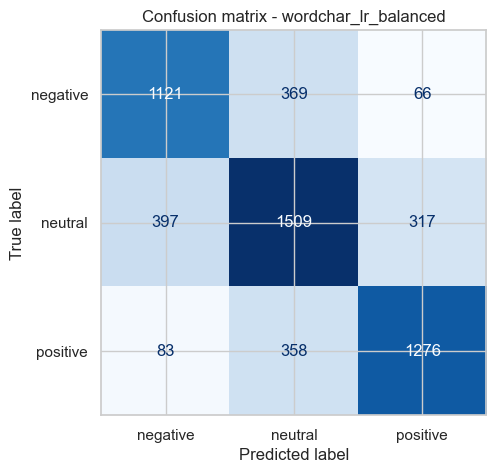

In [17]:
best_name = bench_df.iloc[0]['name']
best_obj = [r for r in bench_rows if r['name'] == best_name][0]
best_model = best_obj['model']
best_pred = best_obj['y_pred']

print('Mejor variante:', best_name)
print('Test F1-macro:', round(best_obj['test_f1_macro'], 4))
print(classification_report(y_test, best_pred, digits=4))

cm = confusion_matrix(y_test, best_pred, labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(cm, display_labels=['negative', 'neutral', 'positive'])
disp.plot(cmap='Blues', colorbar=False)
plt.title(f'Confusion matrix - {best_name}')
plt.show()

## 7) Mini grid de hiperparametros (C + class_weight)

In [18]:
grid_results = []

lr_grid = ParameterGrid({'C': [0.5, 1.0, 2.0, 4.0], 'class_weight': [None, 'balanced']})
for p in lr_grid:
    model = Pipeline([
        ('features', make_union_tfidf()),
        ('clf', LogisticRegression(C=p['C'], class_weight=p['class_weight'], max_iter=3000, random_state=SEED)),
    ])
    row = evaluate_pipeline(f"grid_lr_C{p['C']}_cw{p['class_weight']}", model, X_train_c, y_train, X_test_c, y_test)
    grid_results.append(row)

svc_grid = ParameterGrid({'C': [0.5, 1.0, 2.0, 4.0], 'class_weight': [None, 'balanced']})
for p in svc_grid:
    model = Pipeline([
        ('features', make_union_tfidf()),
        ('clf', LinearSVC(C=p['C'], class_weight=p['class_weight'], random_state=SEED)),
    ])
    row = evaluate_pipeline(f"grid_svc_C{p['C']}_cw{p['class_weight']}", model, X_train_c, y_train, X_test_c, y_test)
    grid_results.append(row)

grid_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['model', 'y_pred']}
    for r in grid_results
]).sort_values(['test_f1_macro', 'cv_f1_macro_mean'], ascending=False).reset_index(drop=True)

display(grid_df.head(12))

,name,cv_f1_macro_mean,cv_f1_macro_std,test_f1_macro,fit_seconds,infer_seconds_test_set
0,grid_lr_C0.5_cwbalanced,0.710935,0.000335,0.714464,4.211496,0.302070
1,grid_lr_C1.0_cwbalanced,0.707921,0.001691,0.714308,4.442255,0.285285
2,grid_lr_C1.0_cwNone,0.702836,0.002027,0.708726,3.254907,0.271914
3,grid_lr_C0.5_cwNone,0.702151,0.000788,0.705912,2.752178,0.275521
4,grid_lr_C2.0_cwbalanced,0.702651,0.002799,0.705902,5.265923,0.393312
5,grid_lr_C2.0_cwNone,0.699333,0.003664,0.702976,4.712647,0.284383
6,grid_lr_C4.0_cwbalanced,0.697559,0.002911,0.698193,4.897868,0.280748
7,grid_lr_C4.0_cwNone,0.696083,0.003567,0.697426,3.569415,0.271953
8,grid_svc_C0.5_cwbalanced,0.695461,0.002012,0.693863,2.460758,0.353763
9,grid_svc_C0.5_cwNone,0.694370,0.001142,0.693470,2.522455,0.387187


## 8) Fijar modelo clasico final

In [19]:
best_grid_name = grid_df.iloc[0]['name']
best_grid_obj = [r for r in grid_results if r['name'] == best_grid_name][0]
classic_final_model = best_grid_obj['model']
classic_final_pred = best_grid_obj['y_pred']

classic_final_f1 = float(f1_score(y_test, classic_final_pred, average='macro'))
classic_final_fit_s = float(best_grid_obj['fit_seconds'])
classic_final_inf_s = float(best_grid_obj['infer_seconds_test_set'])

print('Modelo clasico final:', best_grid_name)
print('F1-macro test:', round(classic_final_f1, 4))
print('fit_seconds:', round(classic_final_fit_s, 4), '| infer_seconds_test_set:', round(classic_final_inf_s, 4))

Modelo clasico final: grid_lr_C0.5_cwbalanced
F1-macro test: 0.7145
fit_seconds: 4.2115 | infer_seconds_test_set: 0.3021


## 9) Fine-tuning Transformer (mismo split train/test)

In [20]:
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

device: cuda


In [21]:
# Split interno para validacion del transformer, sin tocar X_test_raw/y_test
X_tr_tf, X_val_tf, y_tr_tf, y_val_tf = train_test_split(
    X_train_raw, y_train, test_size=0.15, random_state=SEED, stratify=y_train
)

label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}

train_df_tf = pd.DataFrame({'text': X_tr_tf.apply(preprocess_transformer).values, 'label': y_tr_tf.map(label2id).values})
val_df_tf = pd.DataFrame({'text': X_val_tf.apply(preprocess_transformer).values, 'label': y_val_tf.map(label2id).values})
test_df_tf = pd.DataFrame({'text': X_test_raw.apply(preprocess_transformer).values, 'label': y_test.map(label2id).values})

display(train_df_tf.head(2))
print('train/val/test:', len(train_df_tf), len(val_df_tf), len(test_df_tf))

,text,label
0,I`m so tired. I don`t get how I am. I sat on t...,0
1,i kno i doooo!!!!!!!!!! yall partyin with out me,0


train/val/test: 18686 3298 5496


In [22]:
MODEL_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tok(batch):
    return tokenizer(batch['text'], truncation=True, max_length=128)

ds_train_tf = Dataset.from_pandas(train_df_tf).map(tok, batched=True)
ds_val_tf = Dataset.from_pandas(val_df_tf).map(tok, batched=True)
ds_test_tf = Dataset.from_pandas(test_df_tf).map(tok, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model_tf = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    label2id=label2id,
    id2label=id2label,
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 44171.39it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"f1_macro": f1_score(labels, preds, average="macro")}

args = TrainingArguments(
    output_dir="./outputs/twitter_roberta_ft",
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    eval_strategy="epoch",          # <- antes evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    seed=SEED,
    report_to="none",
)

trainer = Trainer(
    model=model_tf,
    args=args,
    train_dataset=ds_train_tf,
    eval_dataset=ds_val_tf,
    processing_class=tokenizer,     # <- antes tokenizer=
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

t0 = time.perf_counter()
trainer.train()
tf_fit_seconds = time.perf_counter() - t0

t1 = time.perf_counter()
pred_out = trainer.predict(ds_test_tf)
tf_infer_seconds = time.perf_counter() - t1

pred_ids = np.argmax(pred_out.predictions, axis=-1)
tf_pred_labels = pd.Series(pred_ids).map(id2label).values
tf_test_f1 = float(f1_score(y_test.reset_index(drop=True), tf_pred_labels, average="macro"))

print("Transformer F1-macro test:", round(tf_test_f1, 4))
print("fit_seconds:", round(tf_fit_seconds, 4), "| infer_seconds_test_set:", round(tf_infer_seconds, 4))
print(classification_report(y_test.reset_index(drop=True), tf_pred_labels, digits=4))

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.498837,0.474790,0.811342
2,0.387377,0.516682,0.804863
3,0.294205,0.566836,0.815022


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.00it/s]


Transformer F1-macro test: 0.805
fit_seconds: 126.7696 | infer_seconds_test_set: 2.8713
              precision    recall  f1-score   support

    negative     0.7955    0.8123    0.8038      1556
     neutral     0.7755    0.7566    0.7659      2223
    positive     0.8400    0.8503    0.8452      1717

    accuracy                         0.8017      5496
   macro avg     0.8037    0.8064    0.8050      5496
weighted avg     0.8013    0.8017    0.8014      5496



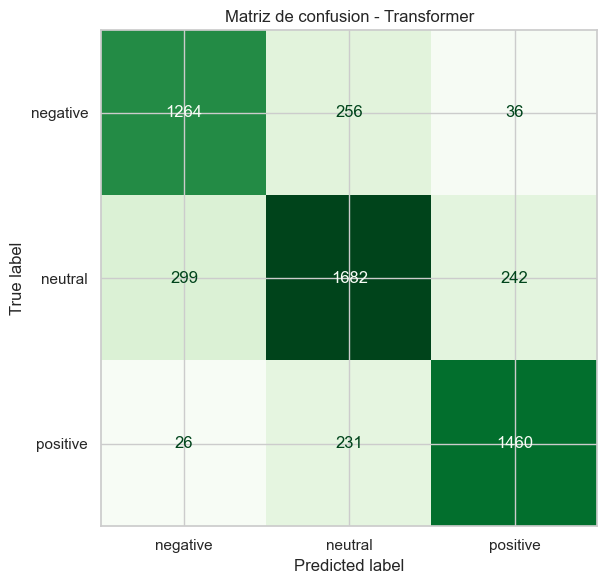

In [30]:
labels = ['negative', 'neutral', 'positive']


cm_tf = confusion_matrix(
    y_test.reset_index(drop=True),
    tf_pred_labels,
    labels=labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tf, display_labels=labels)
disp.plot(ax=ax, cmap='Greens', colorbar=False, values_format='d')
ax.set_title('Matriz de confusion - Transformer')
plt.tight_layout()
plt.show()

## 10) Comparacion final: clasico vs transformer

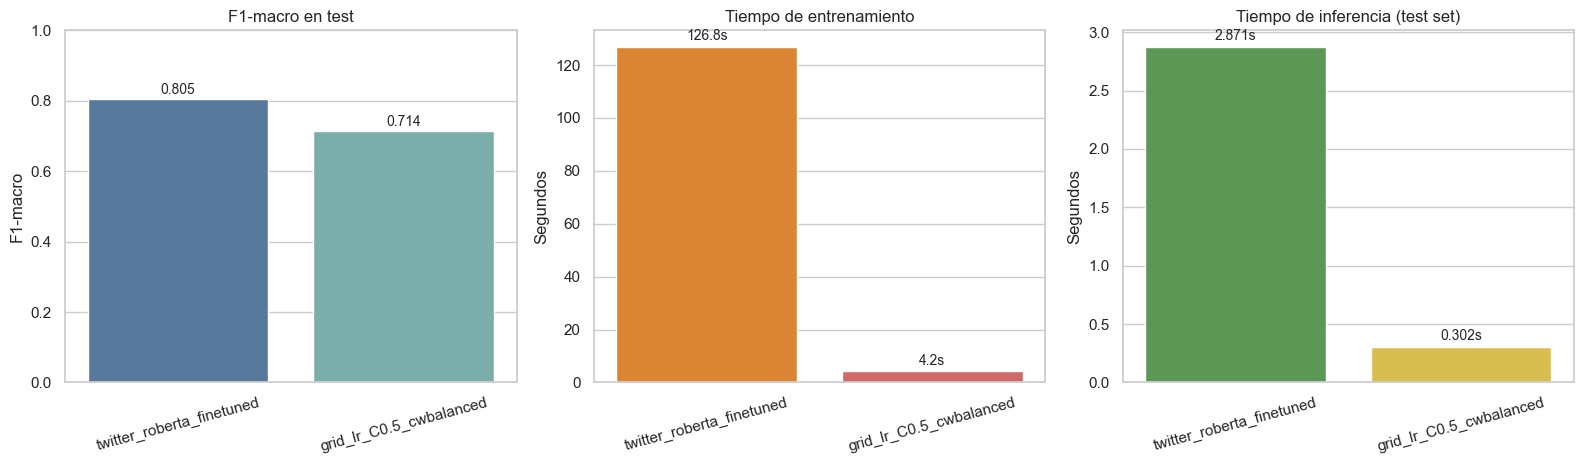

In [32]:
sns.set_theme(style="whitegrid")

# Copia para no modificar original
plot_df = final_cmp.copy()

# --- Figura con 3 paneles ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# 1) F1 macro
sns.barplot(
    data=plot_df, x="model", y="test_f1_macro",
    palette=["#4C78A8", "#72B7B2"], ax=axes[0]
)
axes[0].set_title("F1-macro en test")
axes[0].set_xlabel("")
axes[0].set_ylabel("F1-macro")
axes[0].set_ylim(0, 1)

for i, v in enumerate(plot_df["test_f1_macro"]):
    axes[0].text(i, v + 0.015, f"{v:.3f}", ha="center", fontsize=10)

# 2) Tiempo de entrenamiento
sns.barplot(
    data=plot_df, x="model", y="fit_seconds",
    palette=["#F58518", "#E45756"], ax=axes[1]
)
axes[1].set_title("Tiempo de entrenamiento")
axes[1].set_xlabel("")
axes[1].set_ylabel("Segundos")

for i, v in enumerate(plot_df["fit_seconds"]):
    axes[1].text(i, v + max(plot_df["fit_seconds"]) * 0.02, f"{v:.1f}s", ha="center", fontsize=10)

# 3) Tiempo de inferencia (set de test completo)
sns.barplot(
    data=plot_df, x="model", y="infer_seconds_test_set",
    palette=["#54A24B", "#EECA3B"], ax=axes[2]
)
axes[2].set_title("Tiempo de inferencia (test set)")
axes[2].set_xlabel("")
axes[2].set_ylabel("Segundos")

for i, v in enumerate(plot_df["infer_seconds_test_set"]):
    axes[2].text(i, v + max(plot_df["infer_seconds_test_set"]) * 0.02, f"{v:.3f}s", ha="center", fontsize=10)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

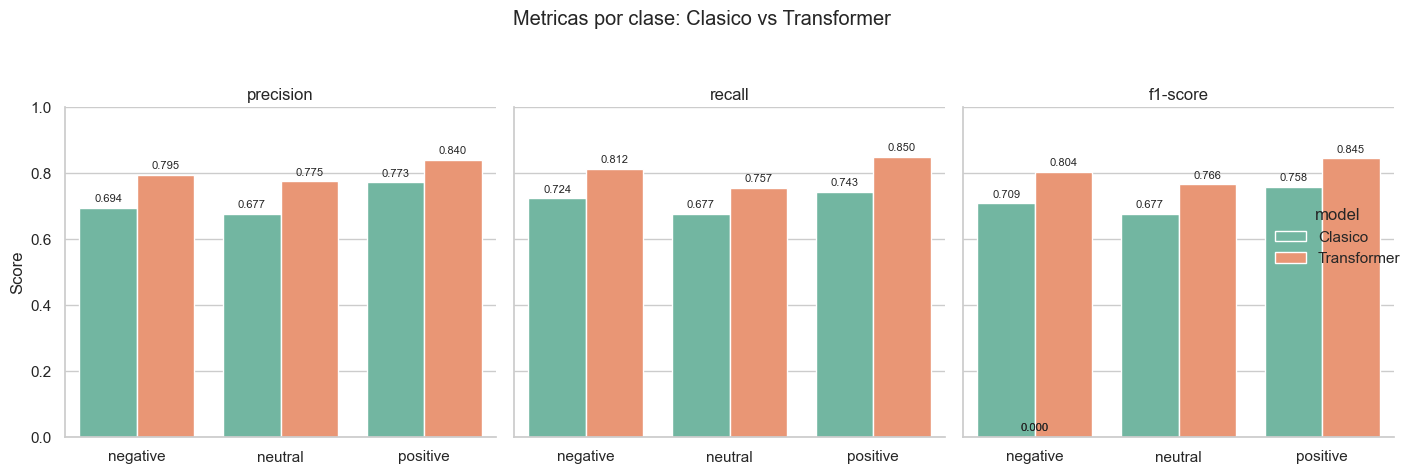

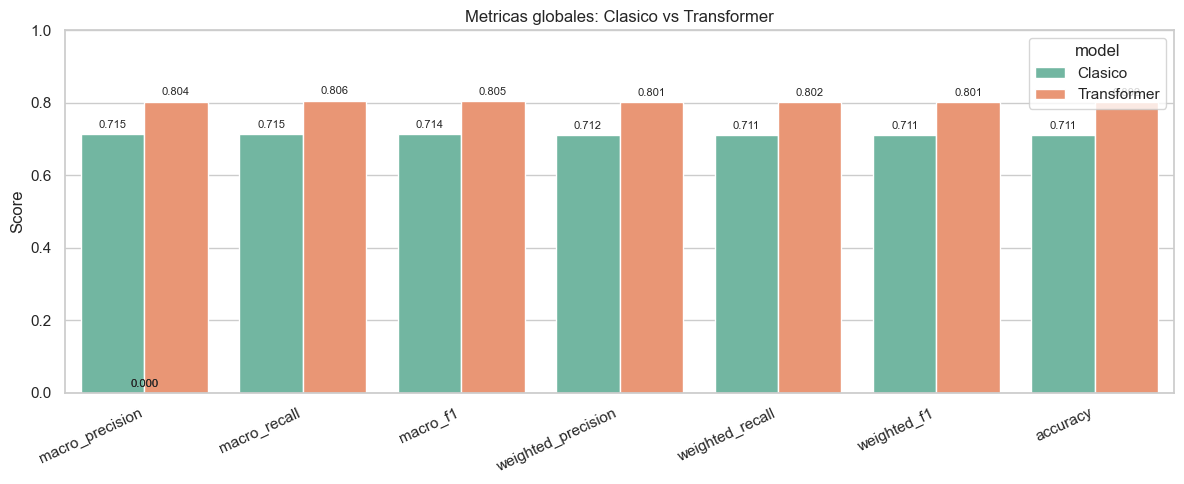

,model,class,precision,recall,f1-score,support
0,Clasico,negative,0.693966,0.724293,0.708805,1556.0
3,Transformer,negative,0.795469,0.812339,0.803816,1556.0
1,Clasico,neutral,0.677172,0.676563,0.676868,2223.0
4,Transformer,neutral,0.775473,0.756635,0.765938,2223.0
2,Clasico,positive,0.772865,0.743157,0.757720,1717.0
5,Transformer,positive,0.840046,0.850320,0.845152,1717.0


model,Clasico,Transformer
metric,,
accuracy,0.7109,0.8017
macro_f1,0.7145,0.8050
macro_precision,0.7147,0.8037
macro_recall,0.7147,0.8064
weighted_f1,0.7112,0.8014
weighted_precision,0.7118,0.8013
weighted_recall,0.7109,0.8017


In [33]:
labels = ['negative', 'neutral', 'positive']

# Reportes en dict
rep_classic = classification_report(
    y_test.reset_index(drop=True),
    classic_final_pred,
    labels=labels,
    output_dict=True,
    zero_division=0
)

rep_tf = classification_report(
    y_test.reset_index(drop=True),
    tf_pred_labels,
    labels=labels,
    output_dict=True,
    zero_division=0
)

# --------- 1) Por clase (negative/neutral/positive) ---------
rows = []
for model_name, rep in [('Clasico', rep_classic), ('Transformer', rep_tf)]:
    for cls in labels:
        rows.append({
            'model': model_name,
            'class': cls,
            'precision': rep[cls]['precision'],
            'recall': rep[cls]['recall'],
            'f1-score': rep[cls]['f1-score'],
            'support': rep[cls]['support'],
        })

df_cls = pd.DataFrame(rows)

# Formato largo para barplot
df_long = df_cls.melt(
    id_vars=['model', 'class', 'support'],
    value_vars=['precision', 'recall', 'f1-score'],
    var_name='metric',
    value_name='value'
)

sns.set_theme(style='whitegrid')
g = sns.catplot(
    data=df_long,
    kind='bar',
    x='class',
    y='value',
    hue='model',
    col='metric',
    palette='Set2',
    height=4.5,
    aspect=0.95
)
g.set(ylim=(0, 1))
g.set_axis_labels("", "Score")
g.set_titles("{col_name}")
for ax in g.axes.flat:
    for p in ax.patches:
        h = p.get_height()
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width()/2, h),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                    textcoords='offset points')
plt.suptitle("Metricas por clase: Clasico vs Transformer", y=1.05)
plt.tight_layout()
plt.show()

# --------- 2) Resumen global (macro avg / weighted avg / accuracy) ---------
summary_rows = []
for model_name, rep in [('Clasico', rep_classic), ('Transformer', rep_tf)]:
    summary_rows.extend([
        {'model': model_name, 'metric': 'macro_precision', 'value': rep['macro avg']['precision']},
        {'model': model_name, 'metric': 'macro_recall', 'value': rep['macro avg']['recall']},
        {'model': model_name, 'metric': 'macro_f1', 'value': rep['macro avg']['f1-score']},
        {'model': model_name, 'metric': 'weighted_precision', 'value': rep['weighted avg']['precision']},
        {'model': model_name, 'metric': 'weighted_recall', 'value': rep['weighted avg']['recall']},
        {'model': model_name, 'metric': 'weighted_f1', 'value': rep['weighted avg']['f1-score']},
        {'model': model_name, 'metric': 'accuracy', 'value': rep['accuracy']},
    ])

df_sum = pd.DataFrame(summary_rows)

plt.figure(figsize=(12, 5))
ax = sns.barplot(data=df_sum, x='metric', y='value', hue='model', palette='Set2')
ax.set_ylim(0, 1)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_title("Metricas globales: Clasico vs Transformer")
plt.xticks(rotation=25, ha='right')
for p in ax.patches:
    h = p.get_height()
    ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width()/2, h),
                ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                textcoords='offset points')
plt.tight_layout()
plt.show()

# Opcional: tabla resumida
display(df_cls.sort_values(['class', 'model']))
display(df_sum.pivot(index='metric', columns='model', values='value').round(4))

In [25]:
err_compare = pd.DataFrame({
    'text': X_test_raw.reset_index(drop=True),
    'real': y_test.reset_index(drop=True),
    'pred_classic': classic_final_pred,
    'pred_transformer': tf_pred_labels,
})

err_compare['classic_ok'] = err_compare['real'] == err_compare['pred_classic']
err_compare['tf_ok'] = err_compare['real'] == err_compare['pred_transformer']

print('Casos donde transformer acierta y clasico falla:', ((~err_compare['classic_ok']) & (err_compare['tf_ok'])).sum())
print('Casos donde clasico acierta y transformer falla:', ((err_compare['classic_ok']) & (~err_compare['tf_ok'])).sum())

display(err_compare.head(10))

Casos donde transformer acierta y clasico falla: 919
Casos donde clasico acierta y transformer falla: 420


,text,real,pred_classic,pred_transformer,classic_ok,tf_ok
0,Reading and taking notes but undertanding none...,negative,negative,negative,True,True
1,so sad emma u sad to be leaving the show? ****,negative,negative,negative,True,True
2,Freakin` frustrated why can`t my coach realize...,negative,negative,negative,True,True
3,is feeling so bored... i miss school time,negative,negative,negative,True,True
4,wow this morning 8.15 hrs ding dong breakfasts...,positive,positive,positive,True,True
5,I am sad... Tanner wasn`t invited to the Panth...,negative,negative,neutral,True,False
6,so hot in the office as air con been broken fo...,negative,negative,negative,True,True
7,Why must Jay Leno leave his own show,neutral,neutral,negative,True,False
8,Hoping that this will just heal on it`s own be...,neutral,negative,neutral,False,True
9,For _inLaPush because she misses Quil so... F...,negative,negative,negative,True,True


## 11) Export automatico de artefactos

In [26]:
import json
import joblib
from pathlib import Path

ART = Path('artifacts')
(ART / 'reports').mkdir(parents=True, exist_ok=True)
(ART / 'predictions').mkdir(parents=True, exist_ok=True)
(ART / 'models' / 'classic').mkdir(parents=True, exist_ok=True)
(ART / 'models' / 'transformer').mkdir(parents=True, exist_ok=True)

final_cmp.to_csv(ART / 'reports' / 'final_comparison.csv', index=False)
err_compare.to_csv(ART / 'predictions' / 'error_comparison.csv', index=False)

print('Guardado:', ART / 'reports' / 'final_comparison.csv')
print('Guardado:', ART / 'predictions' / 'error_comparison.csv')

Guardado: artifacts\reports\final_comparison.csv
Guardado: artifacts\predictions\error_comparison.csv


In [27]:
# Guardar modelo clasico
joblib.dump(classic_final_model, ART / 'models' / 'classic' / 'best_classic_pipeline.pkl')

classic_meta = {
    'model_name': best_grid_name,
    'test_f1_macro': float(classic_final_f1),
    'fit_seconds': float(classic_final_fit_s),
    'infer_seconds_test_set': float(classic_final_inf_s),
    'seed': int(SEED),
}

with open(ART / 'models' / 'classic' / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(classic_meta, f, indent=2)

# Guardar transformer fine-tuned
tf_dir = ART / 'models' / 'transformer' / 'twitter_roberta_finetuned'
tf_dir.mkdir(parents=True, exist_ok=True)
trainer.save_model(str(tf_dir))
tokenizer.save_pretrained(str(tf_dir))

tf_meta = {
    'model_name': 'twitter_roberta_finetuned',
    'base_model': MODEL_NAME,
    'test_f1_macro': float(tf_test_f1),
    'fit_seconds': float(tf_fit_seconds),
    'infer_seconds_test_set': float(tf_infer_seconds),
    'seed': int(SEED),
}

with open(ART / 'models' / 'transformer' / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(tf_meta, f, indent=2)

print('Guardado clasico:', ART / 'models' / 'classic' / 'best_classic_pipeline.pkl')
print('Guardado transformer:', tf_dir)
print('Metadata:', ART / 'models' / 'classic' / 'metadata.json')
print('Metadata:', ART / 'models' / 'transformer' / 'metadata.json')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.35it/s]

Guardado clasico: artifacts\models\classic\best_classic_pipeline.pkl
Guardado transformer: artifacts\models\transformer\twitter_roberta_finetuned
Metadata: artifacts\models\classic\metadata.json
Metadata: artifacts\models\transformer\metadata.json
